In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [ ]:
# Read the data in the CSV file using pandas
red = pd.read_csv(r"/content/drive/MyDrive/AK-CG ML PROJECT/wine+quality/winequality-red.csv", sep=";")
red['wine_type'] = "red"

white = pd.read_csv(r"/content/drive/MyDrive/AK-CG ML PROJECT/wine+quality/winequality-white.csv", sep=";")
white['wine_type'] = "white"

# print(red)
# print(white)

# Combine into one DataFrame
wine_df = pd.concat([red, white], ignore_index=True)

# Reorder columns: move 'wine_type' to 12th position, 'quality' last
cols = list(wine_df.columns)
cols.remove("wine_type")  # remove wine_type from list
cols.remove("quality")    # remove quality from list

cols.insert(11, "wine_type")
cols.append("quality")

# Reindex DataFrame
wine_df = wine_df[cols]

# Check shape
print(wine_df.shape)
print(wine_df["wine_type"].value_counts())
# print(wine_df.head(), "\n\n")
# print(wine_df.tail())


(6497, 13)
wine_type
white    4898
red      1599
Name: count, dtype: int64


# Pre-Processing

1. Check for misisng values and either drop or impute (not needed as no missing values)
2. Categorical -> Numerical
3. Standardise / Normalise

In [ ]:
# Prints concise summary including count of non-null entries and data type of each column
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  wine_type             6497 non-null   object 
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
# check for missing values
print("Number of missing values = ", wine_df.isnull().sum().sum())

Number of missing values =  0


In [ ]:
# label encoding of wine_type with red=0 and white=1
wine_df["wine_type"] = LabelEncoder().fit_transform(wine_df["wine_type"])

# print(wine_df.head())
# print(wine_df.tail())

In [ ]:
# check ranges of each attribute
print(wine_df.describe().T[["min", "max", "mean", "std"]])

# wine_df.hist(bins=20, figsize=(15,10))
# plt.show()


                          min        max        mean        std
fixed acidity         3.80000   15.90000    7.215307   1.296434
volatile acidity      0.08000    1.58000    0.339666   0.164636
citric acid           0.00000    1.66000    0.318633   0.145318
residual sugar        0.60000   65.80000    5.443235   4.757804
chlorides             0.00900    0.61100    0.056034   0.035034
free sulfur dioxide   1.00000  289.00000   30.525319  17.749400
total sulfur dioxide  6.00000  440.00000  115.744574  56.521855
density               0.98711    1.03898    0.994697   0.002999
pH                    2.72000    4.01000    3.218501   0.160787
sulphates             0.22000    2.00000    0.531268   0.148806
alcohol               8.00000   14.90000   10.491801   1.192712
wine_type             0.00000    1.00000    0.753886   0.430779
quality               3.00000    9.00000    5.818378   0.873255


In [ ]:
# standardise all columns except wine_type and quality

num_features = wine_df.columns
num_features = num_features.drop('wine_type')
num_features = num_features.drop('quality')

wine_df1 = wine_df
wine_df[num_features] = StandardScaler().fit_transform(wine_df[num_features])

print(wine_df.describe().T[["min", "max", "mean", "std"]])

# wine_df - with standardising
# wine_df1 - without standardising

                           min        max          mean       std
fixed acidity        -2.634589   6.699425 -3.849639e-16  1.000077
volatile acidity     -1.577330   7.534354  1.049902e-16  1.000077
citric acid          -2.192833   9.231281  2.187295e-17  1.000077
residual sugar       -1.018034  12.686822  3.499672e-17  1.000077
chlorides            -1.342639  15.842187  1.749836e-17  1.000077
free sulfur dioxide  -1.663583  14.563567 -8.749179e-17  1.000077
total sulfur dioxide -1.941780   5.737257 -6.999344e-17  1.000077
density              -2.530192  14.768791 -3.552167e-15  1.000077
pH                   -3.100615   4.923029  2.729744e-15  1.000077
sulphates            -2.091935   9.870879 -5.424491e-16  1.000077
alcohol              -2.089350   3.696231  9.974065e-16  1.000077
wine_type             0.000000   1.000000  7.538864e-01  0.430779
quality               3.000000   9.000000  5.818378e+00  0.873255


In [ ]:
low = wine_df[wine_df['quality'] <= 5].copy()
medium = wine_df[(wine_df['quality'] == 6) | (wine_df['quality'] == 7)].copy()
high = wine_df[wine_df['quality'] > 7].copy()

# label encoding directly
# 0 = low; 1 = medium; 2 = high
low['quality class'] = 0
medium['quality class'] = 1
high['quality class'] = 2

wine_df = pd.concat([low, medium, high], ignore_index=True)

In [ ]:
class_counts = wine_df['quality class'].value_counts()

print(class_counts)

quality class
1    3915
0    2384
2     198
Name: count, dtype: int64


In [ ]:
# removing 'quality' column
z = wine_df['quality']
wine_df = wine_df.drop('quality', axis=1)

# data split
X = wine_df.drop('quality class', axis=1)
y = wine_df['quality class']

In [ ]:
# function to plot metrics vs changing hyperparameters

def plot_metrics(df, x, title, log_scale=False):
    plt.figure(figsize=(8,5))

    # Always convert x column to string to handle mixed types (e.g., gamma)
    x_vals = df[x].astype(str)

    plt.plot(x_vals, df["Mean Accuracy"], marker='o', label="Accuracy")
    plt.plot(x_vals, df["Mean F1 Score"], marker='o', label="F1 Score")
    plt.plot(x_vals, df["Mean AUC ROC"], marker='o', label="AUC RUC")

    # Log scale only applies to true numeric x values
    if log_scale:
        # Only apply log scale if values are numeric
        try:
            numeric_vals = pd.to_numeric(df[x], errors='raise')
            plt.xscale("log")
        except:
            print("⚠ Log scale ignored: X axis contains non-numeric values.")

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid(True)
    plt.show()

# Logistic Regression


In [ ]:
# defualt values for LogisticRegression in skikit

# class sklearn.linear_model.LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1,
# class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)

In [ ]:
# defining all hyperparameter values
penalties = ['none', 'l2', 'l1', 'elasticnet']
solvers = ['liblinear', 'lbfgs', 'saga']
reg_strengths = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [ ]:
lg_solver = []
for solver in solvers:
    model = LogisticRegression(solver = solver, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    lg_solver.append({'Penalty': 'l2',
                'Solver': solver,
                'Regularisation Strength': 1.0,
                'L1 Ratio': 'None',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

lg_penalty = []
for penalty in penalties:
    if penalty == 'elasticnet':
        model = LogisticRegression(penalty = penalty, solver='saga', l1_ratio=0.5, max_iter=10000)
    elif penalty == 'none':
        model = LogisticRegression(penalty = None, solver='saga', max_iter=10000)
    else:
        model = LogisticRegression(penalty = penalty, solver='saga', max_iter=10000)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    lg_penalty.append({'Penalty': penalty,
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': 0.5 if penalty == 'elasticnet' else 'None',
              'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

lg_C = []
for reg_strength in reg_strengths:
    model = LogisticRegression(C=reg_strength, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    lg_C.append({'Penalty': 'l2',
              'Solver': 'lbfgs',
              'Regularisation Strength': reg_strength,
              'L1 Ratio': 'None',
              'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

lg_l1ratio = []
for L1_ratio in L1_ratios:
    model = LogisticRegression(penalty = 'elasticnet',solver='saga',l1_ratio=L1_ratio, max_iter=10000)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    lg_l1ratio.append({'Penalty': 'elasticnet',
              'Solver': 'saga',
              'Regularisation Strength': 1.0,
              'L1 Ratio': L1_ratio,
              'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

In [ ]:
df_lg_solver = pd.DataFrame(lg_solver)
df_lg_penalty = pd.DataFrame(lg_penalty)
df_lg_C = pd.DataFrame(lg_C)
df_lg_l1ratio = pd.DataFrame(lg_l1ratio)

display(df_lg_solver)
print("\n\n")
display(df_lg_penalty)
print("\n\n")
display(df_lg_C)
print("\n\n")
display(df_lg_l1ratio)
print("\n\n")

lg_hp_solv_acc = (df_lg_solver['Mean Accuracy'].var())
lg_hp_pnlt_acc = (df_lg_penalty['Mean Accuracy'].var())
lg_hp_regs_acc = (df_lg_C['Mean Accuracy'].var())
lg_hp_l1ra_acc = (df_lg_l1ratio['Mean Accuracy'].var())

lg_hp_solv_f1 = (df_lg_solver['Mean F1 Score'].var())
lg_hp_pnlt_f1 = (df_lg_penalty['Mean F1 Score'].var())
lg_hp_regs_f1 = (df_lg_C['Mean F1 Score'].var())
lg_hp_l1ra_f1 = (df_lg_l1ratio['Mean F1 Score'].var())

lg_hp_solv_auc = (df_lg_solver['Mean AUC ROC'].var())
lg_hp_pnlt_auc = (df_lg_penalty['Mean AUC ROC'].var())
lg_hp_regs_auc = (df_lg_C['Mean AUC ROC'].var())
lg_hp_l1ra_auc = (df_lg_l1ratio['Mean AUC ROC'].var())

print("Solver (Accuracy): " + str(lg_hp_solv_acc))
print("Penalty (Accuracy): " + str(lg_hp_pnlt_acc))
print("Reg Strength (Accuracy): " + str(lg_hp_regs_acc))
print("L1 Ratio (Accuracy): " + str(lg_hp_l1ra_acc))
print("\n")
print("Solver (F1 Score): " + str(lg_hp_solv_f1))
print("Penalty (F1 Score): " + str(lg_hp_pnlt_f1))
print("Reg Strength (F1 Score): " + str(lg_hp_regs_f1))
print("L1 Ratio (F1 Score): " + str(lg_hp_l1ra_f1))
print("\n")
print("Solver (AUC): " + str(lg_hp_solv_auc))
print("Penalty (AUC): " + str(lg_hp_pnlt_auc))
print("Reg Strength (AUC): " + str(lg_hp_regs_auc))
print("L1 Ratio (AUC): " + str(lg_hp_l1ra_auc))

,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,liblinear,1.0,None,0.684637,0.663829,0.760160
1,l2,lbfgs,1.0,None,0.684328,0.663403,0.759524
2,l2,saga,1.0,None,0.684636,0.663676,0.759426


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,none,saga,1.0,None,0.683405,0.662419,0.758876
1,l2,saga,1.0,None,0.684636,0.663676,0.759426
2,l1,saga,1.0,None,0.684790,0.663752,0.759249
3,elasticnet,saga,1.0,0.5,0.684790,0.663815,0.759395


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,l2,lbfgs,0.001,None,0.671082,0.636314,0.761801
1,l2,lbfgs,0.010,None,0.689712,0.667307,0.764755
2,l2,lbfgs,0.100,None,0.685404,0.664283,0.761492
3,l2,lbfgs,1.000,None,0.684328,0.663403,0.759524
4,l2,lbfgs,10.000,None,0.684021,0.663080,0.759181
5,l2,lbfgs,100.000,None,0.684021,0.663050,0.759010
6,l2,lbfgs,1000.000,None,0.683405,0.662419,0.758997


,Penalty,Solver,Regularisation Strength,L1 Ratio,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,elasticnet,saga,1.0,0.1,0.684636,0.663676,0.759424
1,elasticnet,saga,1.0,0.2,0.684636,0.663676,0.759438
2,elasticnet,saga,1.0,0.3,0.684636,0.663676,0.759424
3,elasticnet,saga,1.0,0.4,0.684636,0.663676,0.759396
4,elasticnet,saga,1.0,0.5,0.684790,0.663815,0.759395
5,elasticnet,saga,1.0,0.6,0.684944,0.663951,0.759393
6,elasticnet,saga,1.0,0.7,0.684944,0.663951,0.759355
7,elasticnet,saga,1.0,0.8,0.684944,0.663951,0.759310
8,elasticnet,saga,1.0,0.9,0.684790,0.663752,0.759267





Solver (Accuracy): 3.1704456347314674e-08
Penalty (Accuracy): 4.498621901165818e-07
Reg Strength (Accuracy): 3.279247835652536e-05
L1 Ratio (Accuracy): 2.0411733286630002e-08


Solver (F1 Score): 4.65359334695004e-08
Penalty (F1 Score): 4.4444991239212176e-07
Reg Strength (F1 Score): 0.00011149373059455592
L1 Ratio (F1 Score): 1.6578835593770542e-08


Solver (AUC): 1.5860493120950862e-07
Penalty (AUC): 6.358835184476208e-08
Reg Strength (AUC): 4.620293250296739e-06
L1 Ratio (AUC): 3.2886968211474963e-09


In [ ]:
lg_summary = pd.DataFrame({
    "Hyperparameter": ["Solver", "Penalty", "C", "L1 Ratio"],
    "Var_Accuracy": [lg_hp_solv_acc, lg_hp_pnlt_acc, lg_hp_regs_acc, lg_hp_l1ra_acc],
    "Var_F1_Score": [lg_hp_solv_f1, lg_hp_pnlt_f1, lg_hp_regs_f1, lg_hp_l1ra_f1],
    "Var_AUC_ROC": [lg_hp_solv_auc, lg_hp_pnlt_auc, lg_hp_regs_auc, lg_hp_l1ra_auc]
})

display(lg_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Solver,3.170446e-08,4.653593e-08,1.586049e-07
1,Penalty,4.498622e-07,4.444499e-07,6.358835e-08
2,C,3.279248e-05,1.114937e-04,4.620293e-06
3,L1 Ratio,2.041173e-08,1.657884e-08,3.288697e-09


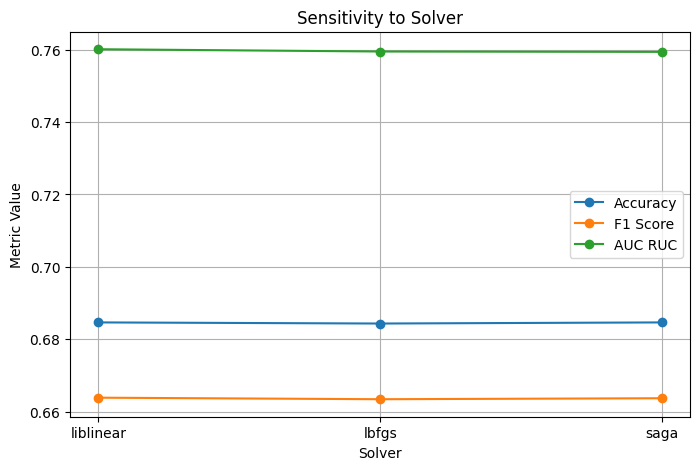

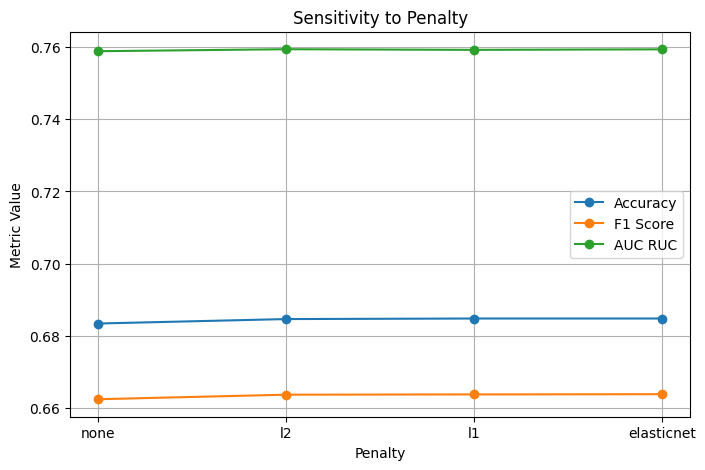

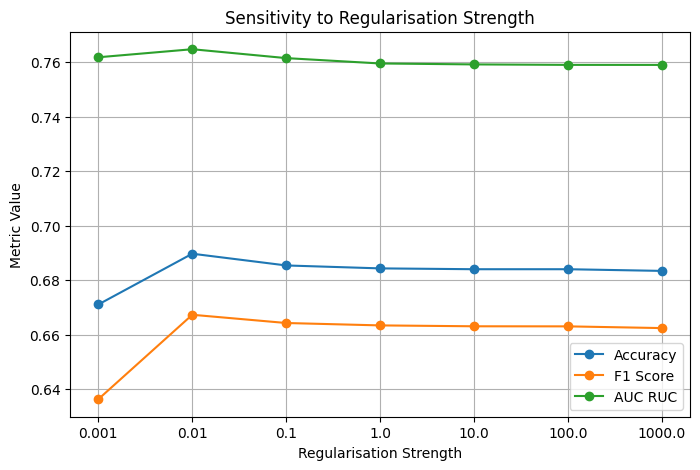

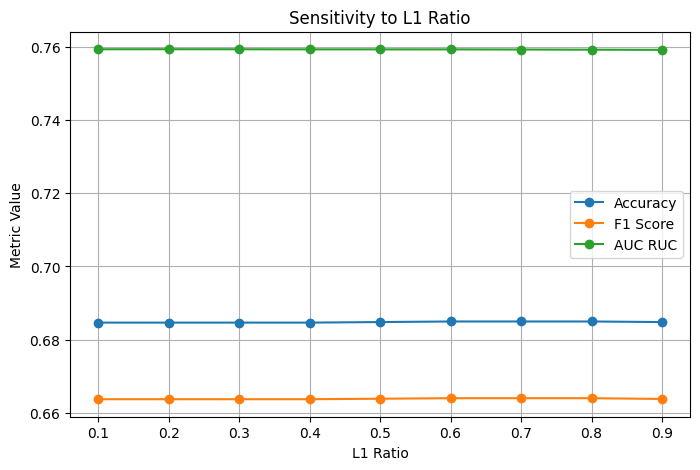

In [ ]:
plot_metrics(df_lg_solver, 'Solver', 'Sensitivity to Solver')
plot_metrics(df_lg_penalty, 'Penalty', 'Sensitivity to Penalty')
plot_metrics(df_lg_C, 'Regularisation Strength', 'Sensitivity to Regularisation Strength')
plot_metrics(df_lg_l1ratio, 'L1 Ratio', 'Sensitivity to L1 Ratio')

# K-Nearest Neighbours

In [ ]:
# defualt values for KNeighborsClassifier in skikit

# class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski',
# metric_params=None, n_jobs=None)

In [ ]:
# defining all hyperparameter values
n_neighbors = [i for i in range(1,32)]
weights = ['uniform','distance']
algorithms = ['auto', 'ball_tree', 'kd_tree', 'brute']
metric = ['euclidean', 'manhattan', 'minkowski','chebyshev','cosine']

In [ ]:
knn_kneighbours = []
for k in n_neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    knn_kneighbours.append({'N Neighbours': k,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})


knn_weightmetric = []
for w in weights:
    model = KNeighborsClassifier(weights=w)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    knn_weightmetric.append({'N Neighbours': 5,
                'Weight Metric': w,
                'Algorithm': 'auto',
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

knn_algorithms = []
for a in algorithms:
    model = KNeighborsClassifier(algorithm=a)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    knn_algorithms.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': a,
                'Distance Metric': 'Euclidean',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

knn_distmetric = []
for d in metric:
    model = KNeighborsClassifier(metric=d)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    knn_distmetric.append({'N Neighbours': 5,
                'Weight Metric': 'uniform',
                'Algorithm': 'auto',
                'Distance Metric': d,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

In [ ]:
df_knn_kneighbours = pd.DataFrame(knn_kneighbours)
df_knn_weightmetric = pd.DataFrame(knn_weightmetric)
df_knn_algorithms = pd.DataFrame(knn_algorithms)
df_knn_distmetric = pd.DataFrame(knn_distmetric)

display(df_knn_kneighbours)
print("\n\n")
display(df_knn_weightmetric)
print("\n\n")
display(df_knn_algorithms)
print("\n\n")
display(df_knn_distmetric)
print("\n\n")

knn_hp_knei_acc = (df_knn_kneighbours['Mean Accuracy'].var())
knn_hp_weig_acc = (df_knn_weightmetric['Mean Accuracy'].var())
knn_hp_algo_acc = (df_knn_algorithms['Mean Accuracy'].var())
knn_hp_dist_acc = (df_knn_distmetric['Mean Accuracy'].var())

knn_hp_knei_f1 = (df_knn_kneighbours['Mean F1 Score'].var())
knn_hp_weig_f1 = (df_knn_weightmetric['Mean F1 Score'].var())
knn_hp_algo_f1 = (df_knn_algorithms['Mean F1 Score'].var())
knn_hp_dist_f1 = (df_knn_distmetric['Mean F1 Score'].var())

knn_hp_knei_auc = (df_knn_kneighbours['Mean AUC ROC'].var())
knn_hp_weig_auc = (df_knn_weightmetric['Mean AUC ROC'].var())
knn_hp_algo_auc = (df_knn_algorithms['Mean AUC ROC'].var())
knn_hp_dist_auc = (df_knn_distmetric['Mean AUC ROC'].var())

print("K Neighbours (Accuracy): " + str(knn_hp_knei_acc))
print("Weight Metric (Accuracy): " + str(knn_hp_weig_acc))
print("Algorithm (Accuracy): " + str(knn_hp_algo_acc))
print("Distance Metric (Accuracy): " + str(knn_hp_dist_acc))
print("\n")
print("K Neighbours (F1 Score): " + str(knn_hp_knei_f1))
print("Weight Metric (F1 Score): " + str(knn_hp_weig_f1))
print("Algorithm (F1 Score): " + str(knn_hp_algo_f1))
print("Distance Metric (F1 Score): " + str(knn_hp_dist_f1))
print("\n")
print("K Neighbours (AUC): " + str(knn_hp_knei_auc))
print("Weight Metric (AUC): " + str(knn_hp_weig_auc))
print("Algorithm (AUC): " + str(knn_hp_algo_auc))
print("Distance Metric (AUC): " + str(knn_hp_dist_auc))

,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1,uniform,auto,Euclidean,0.580921,0.578816,0.582628
1,2,uniform,auto,Euclidean,0.581083,0.575778,0.609586
2,3,uniform,auto,Euclidean,0.600004,0.594627,0.631898
3,4,uniform,auto,Euclidean,0.610165,0.603463,0.645248
4,5,uniform,auto,Euclidean,0.625550,0.614042,0.656460
5,6,uniform,auto,Euclidean,0.627558,0.616878,0.665242
6,7,uniform,auto,Euclidean,0.634168,0.620741,0.675483
7,8,uniform,auto,Euclidean,0.641863,0.629923,0.681436
8,9,uniform,auto,Euclidean,0.640015,0.625624,0.685228
9,10,uniform,auto,Euclidean,0.646327,0.634033,0.689142


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.625550,0.614042,0.656460
1,5,distance,auto,Euclidean,0.619393,0.609707,0.652798


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,Euclidean,0.62555,0.614042,0.65646
1,5,uniform,ball_tree,Euclidean,0.62555,0.614042,0.65646
2,5,uniform,kd_tree,Euclidean,0.62555,0.614042,0.65646
3,5,uniform,brute,Euclidean,0.62555,0.614042,0.65646


,N Neighbours,Weight Metric,Algorithm,Distance Metric,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,5,uniform,auto,euclidean,0.625550,0.614042,0.656460
1,5,uniform,auto,manhattan,0.623089,0.612376,0.654743
2,5,uniform,auto,minkowski,0.625550,0.614042,0.656460
3,5,uniform,auto,chebyshev,0.622472,0.611886,0.662807
4,5,uniform,auto,cosine,0.630632,0.621507,0.667655





K Neighbours (Accuracy): 0.0006243517771964965
Weight Metric (Accuracy): 1.895388007769024e-05
Algorithm (Accuracy): 0.0
Distance Metric (Accuracy): 1.0330171690366339e-05


K Neighbours (F1 Score): 0.0004143203267490049
Weight Metric (F1 Score): 9.3976463915079e-06
Algorithm (F1 Score): 0.0
Distance Metric (F1 Score): 1.5122968695098614e-05


K Neighbours (AUC): 0.0011947437484866482
Weight Metric (AUC): 6.704073239266225e-06
Algorithm (AUC): 0.0
Distance Metric (AUC): 2.962164557755723e-05


In [ ]:
knn_summary = pd.DataFrame({
    "Hyperparameter": ["N Neighbours","Weight Metric","Algorithm","Distance Metric"],
    "Var_Accuracy": [knn_hp_knei_acc, knn_hp_weig_acc, knn_hp_algo_acc, knn_hp_dist_acc],
    "Var_F1_Macro": [knn_hp_knei_f1, knn_hp_weig_f1, knn_hp_algo_f1, knn_hp_dist_f1],
    "Var_AUC_OvR": [knn_hp_knei_auc, knn_hp_weig_auc, knn_hp_algo_auc, knn_hp_dist_auc]
})

display(knn_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Macro,Var_AUC_OvR
0,N Neighbours,0.000624,0.000414,0.001195
1,Weight Metric,0.000019,0.000009,0.000007
2,Algorithm,0.000000,0.000000,0.000000
3,Distance Metric,0.000010,0.000015,0.000030


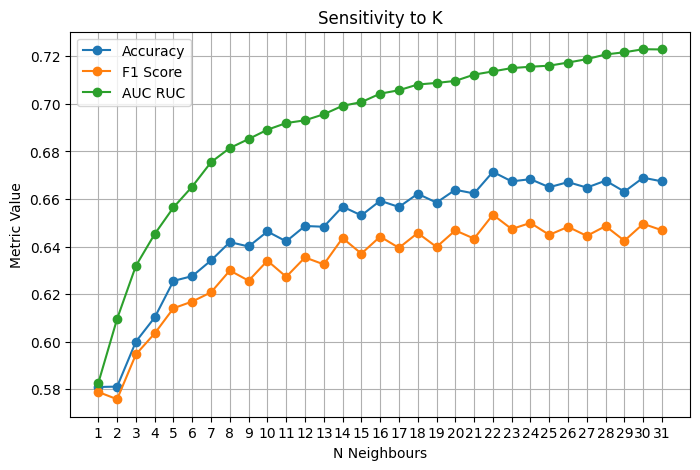

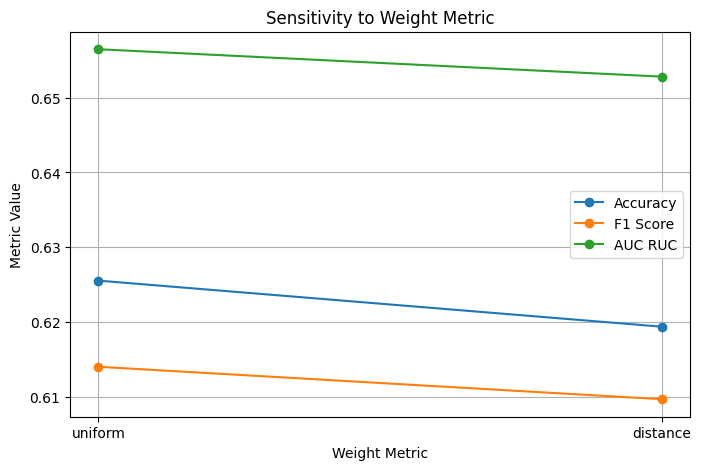

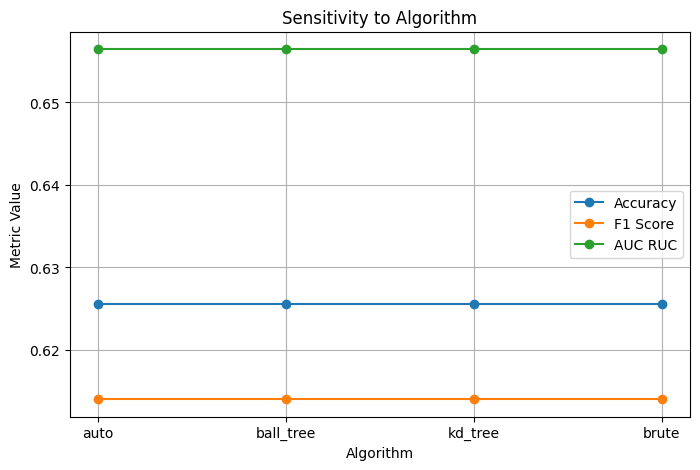

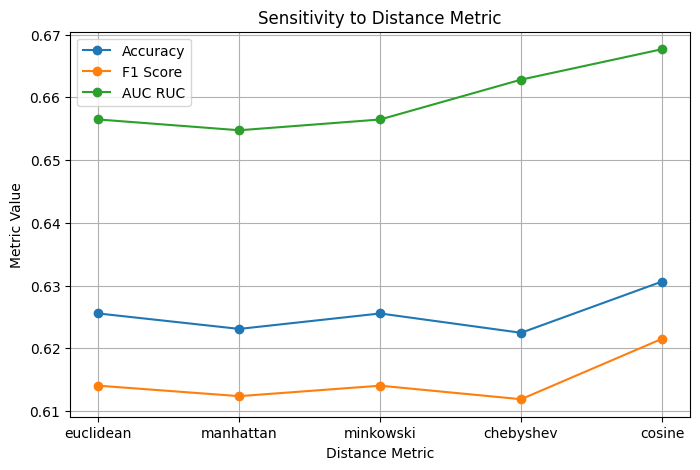

In [ ]:
plot_metrics(df_knn_kneighbours, "N Neighbours", "Sensitivity to K")
plot_metrics(df_knn_weightmetric, "Weight Metric", "Sensitivity to Weight Metric")
plot_metrics(df_knn_algorithms, "Algorithm", "Sensitivity to Algorithm")
plot_metrics(df_knn_distmetric, "Distance Metric", "Sensitivity to Distance Metric")

# Decision Tree

In [ ]:
# defualt values for DecisionTreeClassifier in skikit

# class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1,
# min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None,
# ccp_alpha=0.0, monotonic_cst=None)

In [ ]:
criteria = ['gini','entropy','log_loss']
max_depths = [None,2,3,5,10,15,20]
min_samples_splits = [2,5,10,15,20]
min_samples_leafs = [1,2,5,8,10]
max_features = [None, 'sqrt', 'log2']

In [ ]:
dt_criteria = []
for c in criteria:
    model = DecisionTreeClassifier(criterion=c)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    dt_criteria.append({'Criterion': c,
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

dt_maxdepth = []
for d in max_depths:
    model = DecisionTreeClassifier(criterion='entropy',max_depth=d)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    dt_maxdepth.append({'Criterion': 'entropy',
                'Max Depth': 'none' if d == None else d,
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

dt_minsamplesplit = []
for s in min_samples_splits:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_split=s)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    dt_minsamplesplit.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': s,
                'Min Samples Leaf': 1,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

dt_minsamplesleaf = []
for l in min_samples_leafs:
    model = DecisionTreeClassifier(criterion='entropy',min_samples_leaf=l)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    dt_minsamplesleaf.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': l,
                'Max Features' : 'none',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

dt_maxfeatures = []
for f in max_features:
    model = DecisionTreeClassifier(criterion='entropy',max_features=f)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    dt_maxfeatures.append({'Criterion': 'entropy',
                'Max Depth': 'none',
                'Min Samples Split': 2,
                'Min Samples Leaf': 1,
                'Max Features' : 'none' if f == None else f,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

In [ ]:
df_dt_criteria = pd.DataFrame(dt_criteria)
df_dt_maxdepth = pd.DataFrame(dt_maxdepth)
df_dt_minsamplesplit = pd.DataFrame(dt_minsamplesplit)
df_dt_minsamplesleaf = pd.DataFrame(dt_minsamplesleaf)
df_dt_maxfeatures = pd.DataFrame(dt_maxfeatures)

display(df_dt_criteria)
print("\n\n")
display(df_dt_maxdepth)
print("\n\n")
display(df_dt_minsamplesplit)
print("\n\n")
display(df_dt_minsamplesleaf)
print("\n\n")
display(df_dt_maxfeatures)
print("\n\n")

dt_hp_crit_acc = (df_dt_criteria['Mean Accuracy'].var())
dt_hp_maxd_acc = (df_dt_maxdepth['Mean Accuracy'].var())
dt_hp_split_acc = (df_dt_minsamplesplit['Mean Accuracy'].var())
dt_hp_leaf_acc = (df_dt_minsamplesleaf['Mean Accuracy'].var())
dt_hp_maxf_acc = (df_dt_maxfeatures['Mean Accuracy'].var())

dt_hp_crit_f1 = (df_dt_criteria['Mean F1 Score'].var())
dt_hp_maxd_f1 = (df_dt_maxdepth['Mean F1 Score'].var())
dt_hp_split_f1 = (df_dt_minsamplesplit['Mean F1 Score'].var())
dt_hp_leaf_f1 = (df_dt_minsamplesleaf['Mean F1 Score'].var())
dt_hp_maxf_f1 = (df_dt_maxfeatures['Mean F1 Score'].var())

dt_hp_crit_auc = (df_dt_criteria['Mean AUC ROC'].var())
dt_hp_maxd_auc = (df_dt_maxdepth['Mean AUC ROC'].var())
dt_hp_split_auc = (df_dt_minsamplesplit['Mean AUC ROC'].var())
dt_hp_leaf_auc = (df_dt_minsamplesleaf['Mean AUC ROC'].var())
dt_hp_maxf_auc = (df_dt_maxfeatures['Mean AUC ROC'].var())

print("Criteria (Accuracy) : " + str(dt_hp_crit_acc))
print("Max Depth (Accuracy) : " + str(dt_hp_maxd_acc))
print("Min Samples Split (Accuracy) : " + str(dt_hp_split_acc))
print("Min Samples Leaf (Accuracy) : " + str(dt_hp_leaf_acc))
print("Max Features (Accuracy) : " + str(dt_hp_maxf_acc))
print("\n")
print("Criteria (F1 Score) : " + str(dt_hp_crit_f1))
print("Max Depth (F1 Score) : " + str(dt_hp_maxd_f1))
print("Min Samples Split (F1 Score) : " + str(dt_hp_split_f1))
print("Min Samples Leaf (F1 Score) : " + str(dt_hp_leaf_f1))
print("Max Features (F1 Score) : " + str(dt_hp_maxf_f1))
print("\n")
print("Criteria (AUC) : " + str(dt_hp_crit_auc))
print("Max Depth (AUC) : " + str(dt_hp_maxd_auc))
print("Min Samples Split (AUC) : " + str(dt_hp_split_auc))
print("Min Samples Leaf (AUC) : " + str(dt_hp_leaf_auc))
print("Max Features (AUC) : " + str(dt_hp_maxf_auc))

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,gini,none,2,1,none,0.584444,0.586601,0.595265
1,entropy,none,2,1,none,0.580751,0.579678,0.587233
2,log_loss,none,2,1,none,0.579215,0.577818,0.584491


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.577980,0.577173,0.584465
1,entropy,2,2,1,none,0.677101,0.657696,0.711789
2,entropy,3,2,1,none,0.682948,0.655781,0.742821
3,entropy,5,2,1,none,0.671248,0.655607,0.732969
4,entropy,10,2,1,none,0.622321,0.614619,0.643358
5,entropy,15,2,1,none,0.592142,0.589978,0.596723
6,entropy,20,2,1,none,0.577214,0.576103,0.585540


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.579522,0.577768,0.584813
1,entropy,none,5,1,none,0.577675,0.577181,0.596073
2,entropy,none,10,1,none,0.579676,0.579034,0.606688
3,entropy,none,15,1,none,0.582917,0.580015,0.618751
4,entropy,none,20,1,none,0.590914,0.585157,0.630154


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.584911,0.584255,0.591663
1,entropy,none,2,2,none,0.577526,0.575633,0.592914
2,entropy,none,2,5,none,0.583524,0.581185,0.621740
3,entropy,none,2,8,none,0.600465,0.595075,0.638340
4,entropy,none,2,10,none,0.616013,0.606987,0.654079


,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Max Features,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,entropy,none,2,1,none,0.583984,0.583673,0.591153
1,entropy,none,2,1,sqrt,0.576909,0.577436,0.584497
2,entropy,none,2,1,log2,0.583979,0.584189,0.590706





Criteria (Accuracy) : 7.222352807453438e-06
Max Depth (Accuracy) : 0.0022827158777530714
Min Samples Split (Accuracy) : 2.761378111665997e-05
Min Samples Leaf (Accuracy) : 0.0002446614036174861
Max Features (Accuracy) : 1.667360361624354e-05


Criteria (F1 Score) : 2.1417594503317236e-05
Max Depth (F1 Score) : 0.0014393598212033758
Min Samples Split (F1 Score) : 1.0079003875007011e-05
Min Samples Leaf (F1 Score) : 0.0001554976183317018
Max Features (F1 Score) : 1.4124784022187674e-05


Criteria (AUC) : 3.134825371671928e-05
Max Depth (AUC) : 0.005054222263305602
Min Samples Split (AUC) : 0.0003213815191843985
Min Samples Leaf (AUC) : 0.000759262275373652
Max Features (AUC) : 1.3841695079297013e-05


In [ ]:
dt_summary = pd.DataFrame({
    "Hyperparameter": ["Criterion", "Max Depth", "Min Samples Split", "Min Samples Leaf", "Max Features"],
    "Var_Accuracy": [dt_hp_crit_acc, dt_hp_maxd_acc, dt_hp_split_acc, dt_hp_leaf_acc, dt_hp_maxf_acc],
    "Var_F1_Score": [dt_hp_crit_f1, dt_hp_maxd_f1, dt_hp_split_f1, dt_hp_leaf_f1, dt_hp_maxf_f1],
    "Var_AUC_ROC": [dt_hp_crit_auc, dt_hp_maxd_auc, dt_hp_split_auc, dt_hp_leaf_auc, dt_hp_maxf_auc]
})

display(dt_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Criterion,0.000007,0.000021,0.000031
1,Max Depth,0.002283,0.001439,0.005054
2,Min Samples Split,0.000028,0.000010,0.000321
3,Min Samples Leaf,0.000245,0.000155,0.000759
4,Max Features,0.000017,0.000014,0.000014


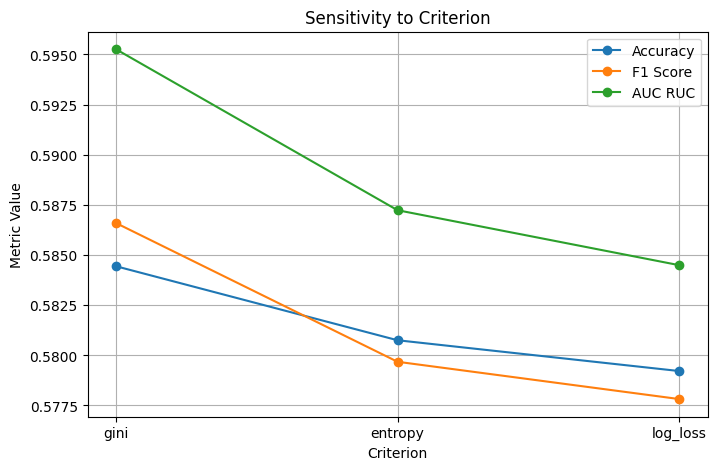

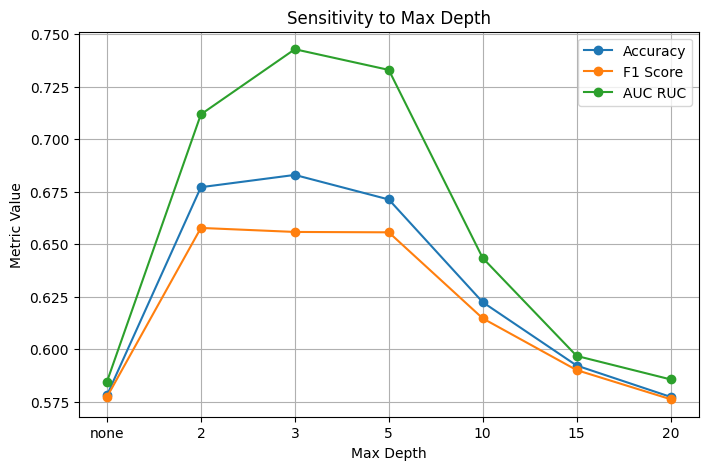

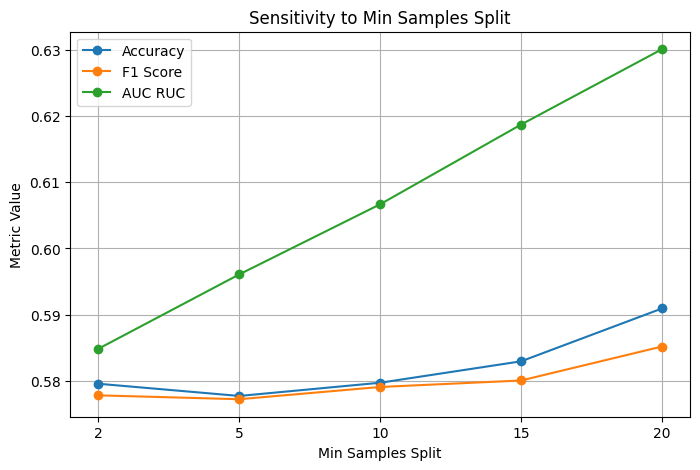

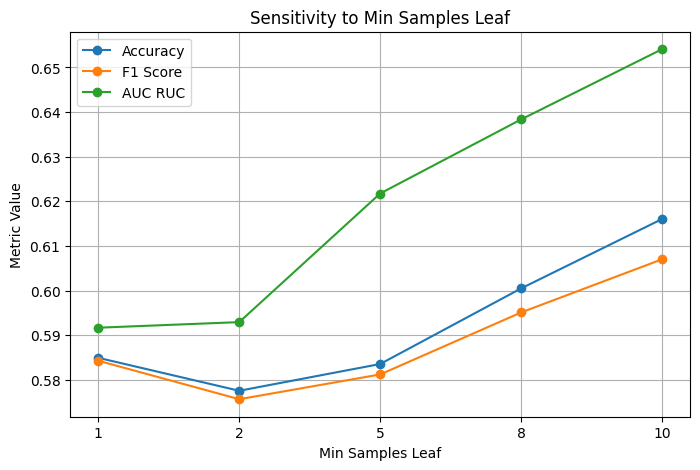

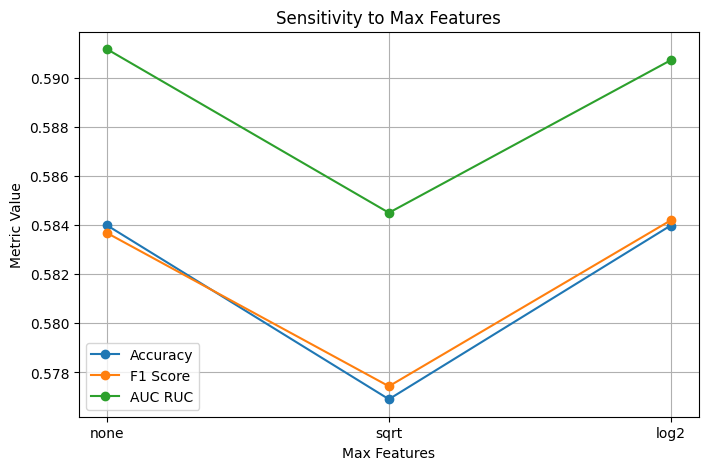

In [ ]:
plot_metrics(df_dt_criteria, "Criterion", "Sensitivity to Criterion")
plot_metrics(df_dt_maxdepth, "Max Depth", "Sensitivity to Max Depth")
plot_metrics(df_dt_minsamplesplit, "Min Samples Split", "Sensitivity to Min Samples Split")
plot_metrics(df_dt_minsamplesleaf, "Min Samples Leaf", "Sensitivity to Min Samples Leaf")
plot_metrics(df_dt_maxfeatures, "Max Features", "Sensitivity to Max Features")

# Support Vector Machine

In [ ]:
# defualt values for SVC in scikit

# class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False,
# tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr',
# break_ties=False, random_state=None)

In [ ]:
# defining all hyperparameter values
C_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
degree_for_poly = [2, 3, 4, 5]
gamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

In [ ]:
svm_C = []
for c in C_vals:
    model = SVC(C=c, probability=True)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    svm_C.append({'C': c,
                'Kernel' : 'rbf',
                'Degree' : 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

svm_kernel = []
for k in kernel:
    model = SVC(kernel=k, probability=True)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    svm_kernel.append({'C': 1.0,
                'Kernel': k,
                'Degree' : 3 if k == 'poly' else 'None',
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

svm_degree_for_poly = []
for d in degree_for_poly:
    model = SVC(kernel='poly', degree=d, probability=True)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    svm_degree_for_poly.append({'C': 1.0,
                'Kernel': 'poly',
                'Degree' : d,
                'Gamma' : 'scale',
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

svm_gamma = []
for g in gamma:
    model = SVC(gamma=g, probability=True)
    scores = cross_validate(model, X, y, cv=10,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    svm_gamma.append({'C': 1.0,
                'Kernel': 'rbf',
                'Degree' : 'None',
                'Gamma' : g,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

In [ ]:
df_svm_C = pd.DataFrame(svm_C)
df_svm_kernel = pd.DataFrame(svm_kernel)
df_svm_degree = pd.DataFrame(svm_degree_for_poly)
df_svm_gamma = pd.DataFrame(svm_gamma)

display(df_svm_C)
print("\n\n")
display(df_svm_kernel)
print("\n\n")
display(df_svm_degree)
print("\n\n")
display(df_svm_gamma)
print("\n\n")


svm_hp_cval_acc = (df_svm_C['Mean Accuracy'].var())
svm_hp_kern_acc = (df_svm_kernel['Mean Accuracy'].var())
svm_hp_degr_acc = (df_svm_degree['Mean Accuracy'].var())
svm_hp_gamm_acc = (df_svm_gamma['Mean Accuracy'].var())

svm_hp_cval_f1 = (df_svm_C['Mean F1 Score'].var())
svm_hp_kern_f1 = (df_svm_kernel['Mean F1 Score'].var())
svm_hp_degr_f1 = (df_svm_degree['Mean F1 Score'].var())
svm_hp_gamm_f1 = (df_svm_gamma['Mean F1 Score'].var())

svm_hp_cval_auc = (df_svm_C['Mean AUC ROC'].var())
svm_hp_kern_auc = (df_svm_kernel['Mean AUC ROC'].var())
svm_hp_degr_auc = (df_svm_degree['Mean AUC ROC'].var())
svm_hp_gamm_auc = (df_svm_gamma['Mean AUC ROC'].var())

print("C (Accuracy) : " + str(svm_hp_cval_acc))
print("Kernel (Accuracy) : " + str(svm_hp_kern_acc))
print("Degree for Poly Kernel (Accuracy) : " + str(svm_hp_degr_acc))
print("Gamma (Accuracy) : " + str(svm_hp_gamm_acc))
print("\n")
print("C (F1 Score) : " + str(svm_hp_cval_f1))
print("Kernel (F1 Score) : " + str(svm_hp_kern_f1))
print("Degree for Poly Kernel (F1 Score) : " + str(svm_hp_degr_f1))
print("Gamma (F1 Score) : " + str(svm_hp_gamm_f1))
print("\n")
print("C (AUC) : " + str(svm_hp_cval_auc))
print("Kernel (AUC) : " + str(svm_hp_kern_auc))
print("Degree for Poly Kernel (AUC) : " + str(svm_hp_degr_auc))
print("Gamma (AUC) : " + str(svm_hp_gamm_auc))
print("\n")

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,0.001,rbf,None,scale,0.602586,0.453156,0.760749
1,0.010,rbf,None,scale,0.624128,0.519911,0.757561
2,0.100,rbf,None,scale,0.679251,0.655464,0.760890
3,1.000,rbf,None,scale,0.687876,0.667831,0.756276
4,10.000,rbf,None,scale,0.680337,0.664840,0.729593
5,100.000,rbf,None,scale,0.634321,0.626011,0.683835
6,1000.000,rbf,None,scale,0.589537,0.586404,0.640847


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,linear,None,scale,0.694179,0.672329,0.760793
1,1.0,poly,3,scale,0.672627,0.646014,0.737008
2,1.0,rbf,None,scale,0.687876,0.667831,0.755368
3,1.0,sigmoid,None,scale,0.606755,0.598226,0.639823


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,poly,2,scale,0.672009,0.642081,0.742168
1,1.0,poly,3,scale,0.672627,0.646014,0.737172
2,1.0,poly,4,scale,0.663388,0.630217,0.731894
3,1.0,poly,5,scale,0.645991,0.603671,0.701541


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,1.0,rbf,None,scale,0.687876,0.667831,0.757129
1,1.0,rbf,None,auto,0.687722,0.667597,0.756770
2,1.0,rbf,None,0.001,0.676624,0.638134,0.766412
3,1.0,rbf,None,0.01,0.685095,0.660396,0.766544
4,1.0,rbf,None,0.1,0.686492,0.666891,0.753572
5,1.0,rbf,None,1,0.635404,0.615629,0.678714





C (Accuracy) : 0.0016073046537618514
Kernel (Accuracy) : 0.0016082934193805004
Degree for Poly Kernel (Accuracy) : 0.00015409992014148003
Gamma (Accuracy) : 0.0004235940104924064


C (F1 Score) : 0.006770177369079043
Kernel (F1 Score) : 0.0011507024622308042
Degree for Poly Kernel (F1 Score) : 0.00036488477192760457
Gamma (F1 Score) : 0.0004595714107316337


C (AUC) : 0.002228478732143134
Kernel (AUC) : 0.003196780816570205
Degree for Poly Kernel (AUC) : 0.0003333172298884148
Gamma (AUC) : 0.0011323373004625866




In [ ]:
svm_summary = pd.DataFrame({
    "Hyperparameter": ["C Value","Kernel","Degree for Polynomial Kernel","Gamma"],
    "Var_Accuracy": [svm_hp_cval_acc, svm_hp_kern_acc, svm_hp_degr_acc, svm_hp_gamm_acc],
    "Var_F1_Score": [svm_hp_cval_f1, svm_hp_kern_f1, svm_hp_degr_f1, svm_hp_gamm_f1],
    "Var_AUC_ROC": [svm_hp_cval_auc, svm_hp_kern_auc, svm_hp_degr_auc, svm_hp_gamm_auc]
})

display(svm_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,C Value,0.001607,0.006770,0.002228
1,Kernel,0.001608,0.001151,0.003197
2,Degree for Polynomial Kernel,0.000154,0.000365,0.000333
3,Gamma,0.000424,0.000460,0.001132


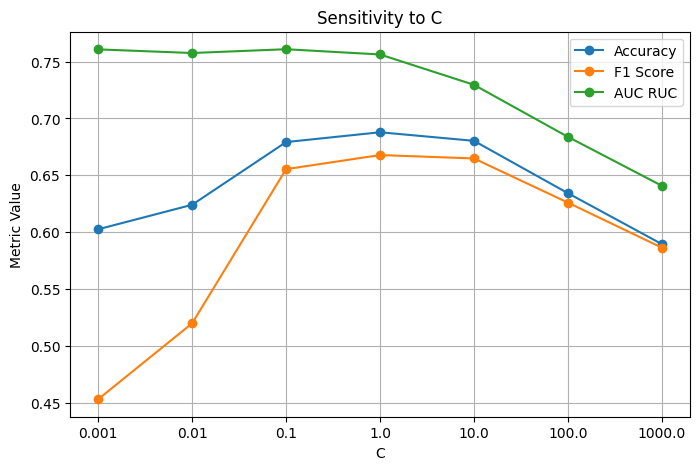

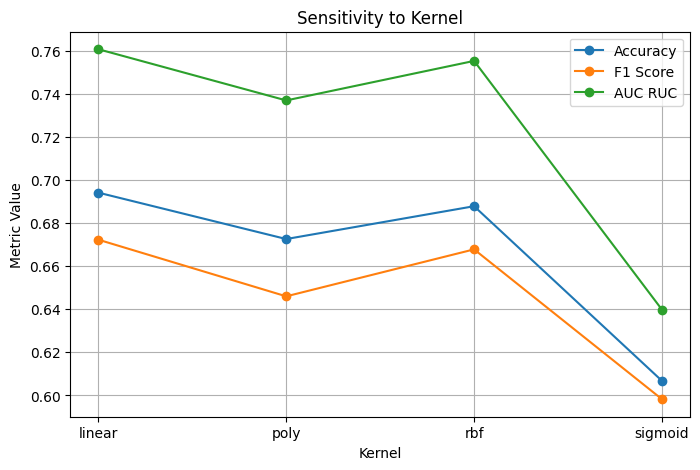

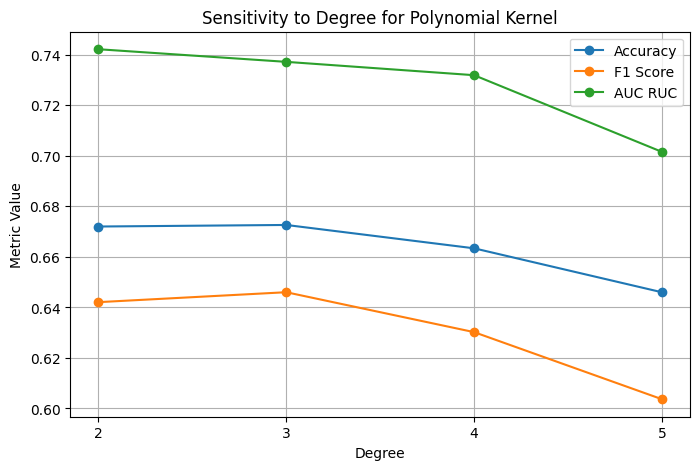

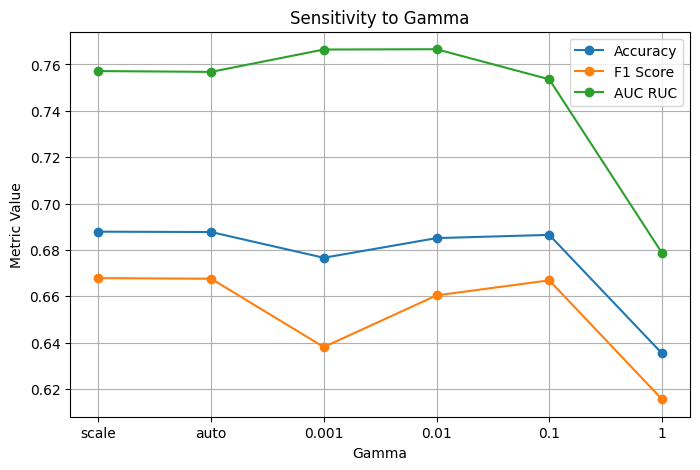

In [ ]:
plot_metrics(df_svm_C, "C", "Sensitivity to C")
plot_metrics(df_svm_kernel, "Kernel", "Sensitivity to Kernel")
plot_metrics(df_svm_degree, "Degree", "Sensitivity to Degree for Polynomial Kernel")
plot_metrics(df_svm_gamma, "Gamma", "Sensitivity to Gamma")

# Neural Network (MLP)

In [ ]:
# defualt values for MLP in scikit

# class sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam',
# alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200,
# shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True,
# early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)

In [ ]:
# defining all hyperparameter values

hidden_layer_sizes = [(10,),(50,),(100,),(10, 10),(50, 50),(100, 50)]
activation = ['identity', 'logistic', 'tanh', 'relu']
alphas = [0.0001, 0.001, 0.01, 0.1,1, 10, 100, 1000]
learning_rate = ['constant', 'invscaling', 'adaptive'] # only if solver is sgd
learning_rate_init = [0.0001, 0.001, 0.01, 0.1]

In [ ]:
mlp_hidden = []
for h in hidden_layer_sizes:
    # had to increase max_iter by A LOT and solver lbfgs is just faster for smaller datasets like iris
    model = MLPClassifier(hidden_layer_sizes=h, solver='lbfgs', max_iter=3000, random_state = 42, early_stopping=True)
    scores = cross_validate(model, X, y, cv=5,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    mlp_hidden.append({'Hidden Layer Sizes': h,
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})


mlp_activation = []
for a in activation:
    model = MLPClassifier(activation=a, max_iter=3000, random_state = 42, early_stopping=True)
    scores = cross_validate(model, X, y, cv=5,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    mlp_activation.append({'Hidden Layer Sizes': (100,),
                'Activation' : a,
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})


mlp_alphas = []
for a in alphas:
    model = MLPClassifier(alpha=a, max_iter=3000, random_state = 42, early_stopping=True)
    scores = cross_validate(model, X, y, cv=5,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    mlp_alphas.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : a,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})


mlp_learning_rate = []
for l in learning_rate:
    model = MLPClassifier(learning_rate=l, solver='sgd', max_iter=3000, random_state = 42, early_stopping=True)
    scores = cross_validate(model, X, y, cv=5,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    mlp_learning_rate.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : l,
                'Learning Rate Init' : 0.001,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})


mlp_learning_rate_init = []
for l in learning_rate_init:
    model = MLPClassifier(learning_rate_init=l, max_iter=3000, random_state = 42, early_stopping=True)
    scores = cross_validate(model, X, y, cv=5,
                            scoring={'acc':'accuracy', 'f1':'f1_weighted', 'auc':'roc_auc_ovr_weighted'}, n_jobs=-1)
    mlp_learning_rate_init.append({'Hidden Layer Sizes': (100,),
                'Activation' : 'relu',
                'Alpha' : 0.0001,
                'Learning Rate' : 'constant',
                'Learning Rate Init' : l,
                'Mean Accuracy': scores['test_acc'].mean(),
                'Mean F1 Score': scores['test_f1'].mean(),
                'Mean AUC ROC': scores['test_auc'].mean()})

In [ ]:
df_mlp_hidden = pd.DataFrame(mlp_hidden)
df_mlp_activation = pd.DataFrame(mlp_activation)
df_mlp_alpha = pd.DataFrame(mlp_alphas)
df_mlp_learning_rate = pd.DataFrame(mlp_learning_rate)
df_mlp_learning_rate_init = pd.DataFrame(mlp_learning_rate_init)

display(df_mlp_hidden)
print("\n\n")
display(df_mlp_activation)
print("\n\n")
display(df_mlp_alpha)
print("\n\n")
display(df_mlp_learning_rate)
print("\n\n")
display(df_mlp_learning_rate_init)
print("\n\n")


mlp_hp_hidd_acc = (df_mlp_hidden['Mean Accuracy'].var())
mlp_hp_acti_acc = (df_mlp_activation['Mean Accuracy'].var())
mlp_hp_alph_acc = (df_mlp_alpha['Mean Accuracy'].var())
mlp_hp_lear_acc = (df_mlp_learning_rate['Mean Accuracy'].var())
mlp_hp_inlr_acc = (df_mlp_learning_rate_init['Mean Accuracy'].var())

mlp_hp_hidd_f1 = (df_mlp_hidden['Mean F1 Score'].var())
mlp_hp_acti_f1 = (df_mlp_activation['Mean F1 Score'].var())
mlp_hp_alph_f1 = (df_mlp_alpha['Mean F1 Score'].var())
mlp_hp_lear_f1 = (df_mlp_learning_rate['Mean F1 Score'].var())
mlp_hp_inlr_f1 = (df_mlp_learning_rate_init['Mean F1 Score'].var())

mlp_hp_hidd_auc = (df_mlp_hidden['Mean AUC ROC'].var())
mlp_hp_acti_auc = (df_mlp_activation['Mean AUC ROC'].var())
mlp_hp_alph_auc = (df_mlp_alpha['Mean AUC ROC'].var())
mlp_hp_lear_auc = (df_mlp_learning_rate['Mean AUC ROC'].var())
mlp_hp_inlr_auc = (df_mlp_learning_rate_init['Mean AUC ROC'].var())

print("Hidden Layer Sizes (Accuracy) : " + str(mlp_hp_hidd_acc))
print("Activation Function (Accuracy) : " + str(mlp_hp_acti_acc))
print("Alpha (Accuracy) : " + str(mlp_hp_alph_acc))
print("Learning Rate (Accuracy) : " + str(mlp_hp_lear_acc))
print("Learning Rate Init (Accuracy) : " + str(mlp_hp_inlr_acc))
print("\n")
print("Hidden Layer Sizes (F1 Score) : " + str(mlp_hp_hidd_f1))
print("Activation Function (F1 Score) : " + str(mlp_hp_acti_f1))
print("Alpha (F1 Score) : " + str(mlp_hp_alph_f1))
print("Learning Rate (F1 Score) : " + str(mlp_hp_lear_f1))
print("Learning Rate Init (F1 Score) : " + str(mlp_hp_inlr_f1))
print("\n")
print("Hidden Layer Sizes (AUC) : " + str(mlp_hp_hidd_auc))
print("Activation Function (AUC) : " + str(mlp_hp_acti_auc))
print("Alpha (AUC) : " + str(mlp_hp_alph_auc))
print("Learning Rate (AUC) : " + str(mlp_hp_lear_auc))
print("Learning Rate Init (AUC) : " + str(mlp_hp_inlr_auc))

,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(10,)",relu,0.0001,constant,0.001,0.639867,0.604733,0.739539
1,"(50,)",relu,0.0001,constant,0.001,0.607378,0.587497,0.694197
2,"(100,)",relu,0.0001,constant,0.001,0.574280,0.560482,0.652583
3,"(10, 10)",relu,0.0001,constant,0.001,0.631856,0.606249,0.719266
4,"(50, 50)",relu,0.0001,constant,0.001,0.576589,0.569079,0.631257
5,"(100, 50)",relu,0.0001,constant,0.001,0.588140,0.576555,0.654028


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",identity,0.0001,constant,0.001,0.652171,0.626087,0.750512
1,"(100,)",logistic,0.0001,constant,0.001,0.650634,0.621903,0.756104
2,"(100,)",tanh,0.0001,constant,0.001,0.654789,0.625174,0.763900
3,"(100,)",relu,0.0001,constant,0.001,0.639251,0.603268,0.745194


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.639251,0.603268,0.745194
1,"(100,)",relu,0.0010,constant,0.001,0.639713,0.603694,0.745705
2,"(100,)",relu,0.0100,constant,0.001,0.640021,0.603845,0.745518
3,"(100,)",relu,0.1000,constant,0.001,0.644636,0.611054,0.750565
4,"(100,)",relu,1.0000,constant,0.001,0.640789,0.604412,0.749854
5,"(100,)",relu,10.0000,constant,0.001,0.646629,0.608746,0.749287
6,"(100,)",relu,100.0000,constant,0.001,0.599510,0.485011,0.619014
7,"(100,)",relu,1000.0000,constant,0.001,0.598124,0.462108,0.604822


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.001,0.642479,0.607516,0.751554
1,"(100,)",relu,0.0001,invscaling,0.001,0.580277,0.486513,0.584641
2,"(100,)",relu,0.0001,adaptive,0.001,0.642325,0.607280,0.751305


,Hidden Layer Sizes,Activation,Alpha,Learning Rate,Learning Rate Init,Mean Accuracy,Mean F1 Score,Mean AUC ROC
0,"(100,)",relu,0.0001,constant,0.0001,0.642326,0.605667,0.750582
1,"(100,)",relu,0.0001,constant,0.0010,0.639251,0.603268,0.745194
2,"(100,)",relu,0.0001,constant,0.0100,0.647098,0.611748,0.755380
3,"(100,)",relu,0.0001,constant,0.1000,0.653254,0.627442,0.744083





Hidden Layer Sizes (Accuracy) : 0.0007908390020829941
Activation Function (Accuracy) : 4.70319762156264e-05
Alpha (Accuracy) : 0.0004033979481233471
Learning Rate (Accuracy) : 0.0012865261475706602
Learning Rate Init (Accuracy) : 3.7266759781398954e-05


Hidden Layer Sizes (F1 Score) : 0.0003536423447306997
Activation Function (F1 Score) : 0.00011473742832108077
Alpha (F1 Score) : 0.0037944152991229926
Learning Rate (F1 Score) : 0.004871086571329725
Learning Rate Init (F1 Score) : 0.00011828684504943331


Hidden Layer Sizes (AUC) : 0.0018141368913459088
Activation Function (AUC) : 6.404565228901717e-05
Alpha (AUC) : 0.003968713551508639
Learning Rate (AUC) : 0.009272781035046305
Learning Rate Init (AUC) : 2.724167020835433e-05


In [ ]:
mlp_summary = pd.DataFrame({
    "Hyperparameter": ["Hidden Layers Size", "Activation Function", "Alpha", "Learning Rate", "Learning Rate Initial"],
    "Var_Accuracy": [mlp_hp_hidd_acc, mlp_hp_acti_acc, mlp_hp_alph_acc, mlp_hp_lear_acc, mlp_hp_inlr_acc],
    "Var_F1_Score": [mlp_hp_hidd_f1, mlp_hp_acti_f1, mlp_hp_alph_f1, mlp_hp_lear_f1, mlp_hp_inlr_f1],
    "Var_AUC_ROC": [mlp_hp_hidd_acc, mlp_hp_acti_auc, mlp_hp_alph_auc, mlp_hp_lear_auc, mlp_hp_inlr_auc]
})

display(mlp_summary)

,Hyperparameter,Var_Accuracy,Var_F1_Score,Var_AUC_ROC
0,Hidden Layers Size,0.000791,0.000354,0.000791
1,Activation Function,0.000047,0.000115,0.000064
2,Alpha,0.000403,0.003794,0.003969
3,Learning Rate,0.001287,0.004871,0.009273
4,Learning Rate Initial,0.000037,0.000118,0.000027


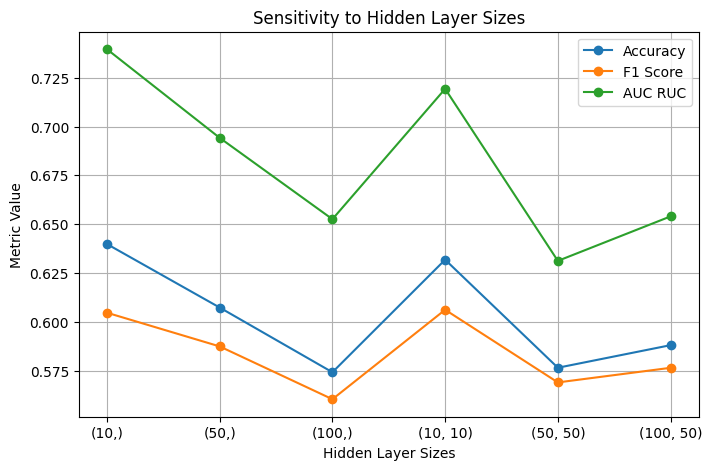

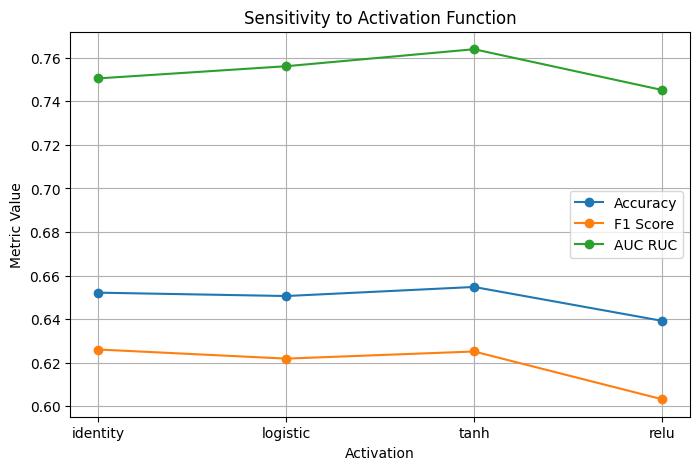

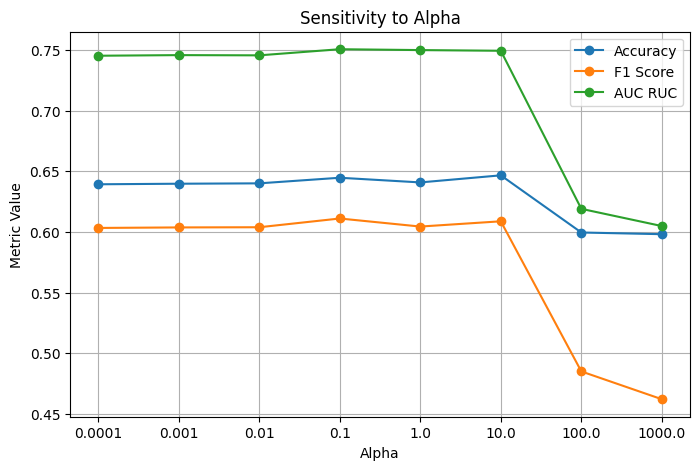

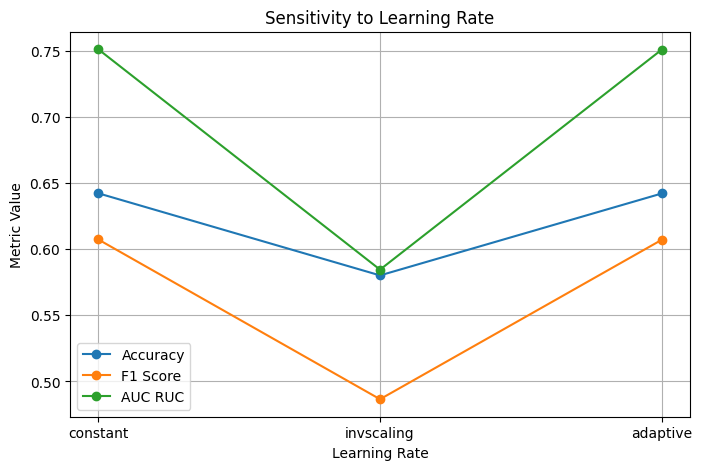

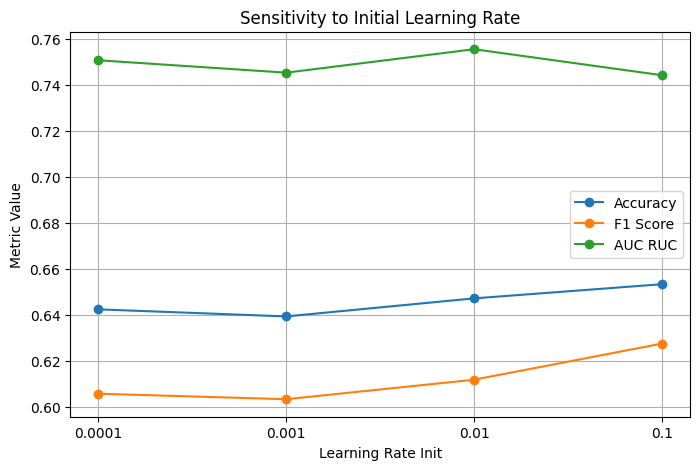

In [ ]:
plot_metrics(df_mlp_hidden, "Hidden Layer Sizes", "Sensitivity to Hidden Layer Sizes")
plot_metrics(df_mlp_activation, "Activation", "Sensitivity to Activation Function")
plot_metrics(df_mlp_alpha, "Alpha", "Sensitivity to Alpha")
plot_metrics(df_mlp_learning_rate, "Learning Rate", "Sensitivity to Learning Rate")
plot_metrics(df_mlp_learning_rate_init, "Learning Rate Init", "Sensitivity to Initial Learning Rate")